# In-Depth CNN Image Operations Explained

### 1. Library Integration and Data Acquisition
* **OpenCV Library (`cv2`)**: **Serves as the core engine for image processing. It treats images as multi-dimensional matrices, allowing for high-performance mathematical operations on pixel data.**
* **Image Loading Function**: **Retrieves the raw bytes from storage and decodes them into a structured NumPy array. This is the moment static data is converted into a mathematical format the computer can manipulate.**
* **BGR Color Architecture**: **It is critical to note that OpenCV uses a Blue-Green-Red (BGR) color model. This legacy architectural choice means that without conversion, the standard order of color information is reversed compared to most modern display software.**

[Image of digital image pixel representation matrix]

### 2. Structural Analysis (Shape and Dimensions)
* **Matrix Inspection**: **Viewing the raw variable reveals the "Tensor" nature of an image—a massive collection of nested lists where each number represents the intensity of a specific color at a specific coordinate.**
* **Shape Properties**: **The dimensions (Height, Width, Channels) define the total resolution and depth. For instance, a 1920x1250 image with 3 channels contains over 7 million individual data points that the model must eventually process.**

### 3. Color Space Optimization
* **Matplotlib Visualization**: **This library acts as the bridge between raw data and human-readable images, allowing for visual debugging of the preprocessing pipeline.**
* **RGB Conversion Logic**: **To ensure visual accuracy, the BGR matrix is reordered to RGB (Red-Green-Blue). This alignment is essential for human verification; otherwise, the Red and Blue channels are swapped, leading to distorted visual representations.**

### 4. Dimensional Standardization (Resizing)
* **The Fixed-Input Constraint**: **Neural Networks are built with a fixed number of input neurons. Consequently, every image entering a CNN must be the exact same size regardless of its original aspect ratio.**
* **Resolution Reduction (16x16)**: **Downsampling significantly reduces the feature space. By shrinking an image, we retain the most prominent global patterns (like general shapes) while discarding high-frequency noise and drastically lowering the computational power required for training.**

[Image of image resizing interpolation process]

### 5. Grayscale Dimensionality Reduction
* **Luminance Extraction**: **This process mathematically blends the three color channels into one based on human perception of brightness. It transforms a 3D color cube into a 2D intensity map.**
* **Computational Efficiency**: **In many CNN tasks (like character or edge recognition), color is redundant information. Dropping from three channels to one reduces the model's memory footprint and training time by roughly 66% without losing structural features.**

[Image of RGB to grayscale conversion process]

### 6. Spatial Slicing (Cropping)
* **Region of Interest (ROI)**: **By selecting specific index ranges in the matrix, we isolate the most important part of the image. This mimics a "zoom" effect, removing background clutter that might confuse the model.**
* **Array Indexing Mechanics**: **Because images are treated as Cartesian coordinate systems, slicing by rows and columns allows for surgical precision in selecting pixels from the top-left or center of the frame.**

[Image of 2D array slicing for image cropping]

### 7. Comparative Visualization (Subplots)
* **Subplot Architecture**: **This organizes multiple visual outputs into a single cohesive frame. It allows for direct side-by-side comparison between the original high-resolution image and the processed, resized, or cropped versions.**
* **Rendering and Buffering**: **The final display command flushes the graphics buffer to the screen, turning the hidden mathematical transformations into a visible result that verifies the success of the preprocessing steps.**

# RGB Color Visualization: In-Depth Explanation

### 1. Library Integration and Data Acquisition
* **`import matplotlib.pyplot as plt`**: **Imports the primary visualization library used to render the final color block. It converts the abstract numerical data into a visual representation.**
* **`import numpy as np`**: **Imports the fundamental numerical library. In Python, images are treated as NumPy arrays, allowing us to build the color block using mathematical matrices.**
* **`input()`**: **Acts as the bridge between the user and the code. It captures specific intensity values for the Red, Green, and Blue channels, which define the final pixel color.**



[Image of RGB color model additive mixing]


### 2. Creating the Image Array (Color Block)
* **`np.zeros((100, 100, 3), dtype=np.uint8)`**: **Initializes a 3D matrix. The (100, 100) sets the resolution, while the '3' represents the three color channels. 'uint8' ensures the numbers are stored as 8-bit integers, which is the standard format for colors (0 to 255).**
* **`color_block[:, :, 0] = r`**: **Directly assigns the user-defined Red value to the first channel across every pixel in the matrix. This is known as array slicing.**
* **`color_block[:, :, 1] = g`**: **Populates the second channel with the Green intensity, determining how much "green light" is mixed into the final image.**
* **`color_block[:, :, 2] = b`**: **Populates the third channel with the Blue intensity, completing the three-part color coordinate.**



### 3. Displaying and Labeling
* **`plt.imshow()`**: **Translates the 3D matrix into a visual image. It interprets the three numerical values at each pixel location to produce a specific shade.**
* **`plt.axis("off")`**: **Removes the x and y coordinate labels. Since we are viewing a solid color rather than a graph, this provides a cleaner and more professional visual output.**
* **`plt.title()`**: **Dynamically generates a heading that displays the exact RGB values entered by the user. This serves as a reference for the visual output.**
* **`plt.show()`**: **Commands the notebook to flush the graphics buffer and display the finalized image on the screen.**

Enter Red value (0-255): 255
Enter Green value (0-255): 255
Enter Blue value (0-255): 0


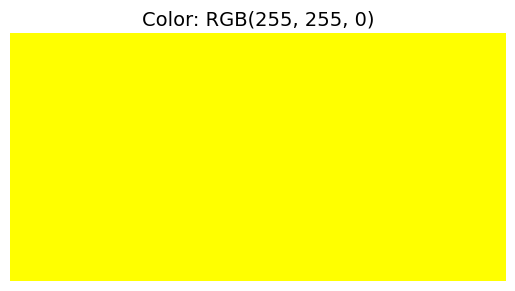

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# Ask user for RGB values
r = int(input("Enter Red value (0-255): "))      # Get Red value
g = int(input("Enter Green value (0-255): "))    # Get Green value
b = int(input("Enter Blue value (0-255): "))    # Get Blue value

# Create a color block
color_block = np.zeros((100, 200, 3), dtype=np.uint8)
# Creates a 100×200 image with 3 channels: R, G, B.
# Initially, all pixel values are 0 (black).

color_block[:, :, 0] = r  # Put Red value in channel 0
color_block[:, :, 1] = g  # Put Green value in channel 1
color_block[:, :, 2] = b  # Put Blue value in channel 2

# Show the color
plt.imshow(color_block)  # Displays the created RGB color

plt.axis("off")  # Removes x and y axes
plt.title(f"Color: RGB({r}, {g}, {b})", fontsize=14)  # Displays RGB values
plt.show()  # Shows the color block


# Pixel-Level Color Manipulation: In-Depth Explanation

### 1. Library Initialization and Image Loading
* **`import cv2`**: **Imports the OpenCV library, which provides the mathematical framework for treating digital images as high-dimensional matrices.**
* **`import matplotlib.pyplot as plt`**: **Imports the visualization engine used to render the final array into a viewable picture within the notebook environment.**
* **`cv2.imread()`**: **Decodes the raw image file from storage into a three-dimensional NumPy array. By default, it stores color channels in BGR (Blue-Green-Red) order.**
* **`cv2.cvtColor(img, cv2.COLOR_BGR2RGB)`**: **Reorders the image channels to the standard RGB (Red-Green-Blue) format. This step is critical for accurate color rendering in Matplotlib, ensuring the "Red" channel is at index 0 and "Blue" is at index 2.**



### 2. Manual Color Channel Overriding
* **`img[:, :, 0] = 150`**: **Performs a global modification of the "Red" channel. By using the colon syntax (`:`), the code targets every single row and column (every pixel) and forces its Red intensity value to exactly 150.**
* **`img[:, :, 2] = 255`**: **Forces the "Blue" channel to its maximum intensity across the entire image. In additive color theory, setting a channel to 255 creates full brightness for that specific color component.**
* **Resulting Color Logic**: **Because the Green channel (index 1) remains untouched while Red is dimmed and Blue is maximized, the original image details will now appear through a heavy Magenta/Violet tint, as Blue and Red light are being blended together.**



### 3. Rendering and Axis Management
* **`plt.imshow(img)`**: **Translates the modified 3D numerical matrix back into a visual format. It maps the modified Red, Green, and Blue integers at each coordinate to the corresponding light intensity on your screen.**
* **`plt.title()`**: **Applies a text header to the display area to document the specific transformation performed on the data.**
* **`plt.axis("off")`**: **Suppresses the pixel coordinate system (the x and y scales). This is done to treat the output purely as a visual artwork rather than a scientific graph.**
* **`plt.show()`**: **Finalizes the plotting instructions and outputs the transformed image directly into the notebook cell.**

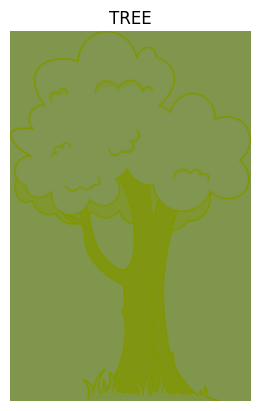

In [8]:
import cv2
import matplotlib.pyplot as plt

# Load the image
img = cv2.imread("/content/tree-clipart.png")
# Reads the image using OpenCV.

img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
# Converts OpenCV's BGR format to RGB format for correct display.

# Change RGB channel values
img[:, :, 0] = 128
# Sets every RED pixel value to 128.

img[:, :, 1] = 150
# Sets every GREEN pixel value to 150.

# img[:, :, 2] = 0
# Would set every BLUE pixel value to 0, but this line is commented out.

# Show result
plt.imshow(img)
# Displays the modified image.

plt.title("TREE")
# Sets the title to "TREE".

plt.axis("off")
# Hides the x and y axes.

plt.show()
# Displays the final image.


**bold text**# Grayscale Conversion and Colormap Visualization: In-Depth Explanation

### 1. Library Initialization and Image Acquisition
* **`import cv2`**: **Imports the OpenCV library, which serves as the fundamental toolkit for image decoding and pixel manipulation.**
* **`import matplotlib.pyplot as plt`**: **Imports the visualization module used to render the numerical data into a visual format that can be displayed within the notebook.**
* **`cv2.imread()`**: **Reads the source image file and translates it into a 3D NumPy array where color data is stored in the Blue-Green-Red (BGR) format.**

### 2. Grayscale Transformation Logic
* **`cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)`**: **Mathematically collapses the three color channels (Red, Green, and Blue) into a single intensity channel. This is achieved by taking a weighted average of the color values to represent the brightness (luminance) of each pixel.**
* **Dimensionality Reduction**: **The image is transformed from a 3D matrix (Height, Width, 3) to a 2D matrix (Height, Width). This significantly simplifies the data structure, which is a common preprocessing step for tasks like edge detection or character recognition.**



### 3. Colormap Application and Mapping
* **`plt.imshow(gray, cmap='gray')`**: **Maps the single-channel intensity values (0-255) to a specific visual scale. While the 'gray' colormap shows shades from black to white, other maps like 'jet' or 'viridis' can map these brightness levels to different colors.**
* **Visualizing Gradients**: **Using different colormaps can help highlight subtle changes in intensity that might be difficult for the human eye to see in standard grayscale.**



### 4. Final Display and Formatting
* **`plt.axis("off")`**: **Suppresses the pixel coordinate system and measurement markers. This allows the user to focus entirely on the image content without the distraction of numerical axes.**
* **`plt.show()`**: **Finalizes the rendering process and outputs the image directly into the cell output area.**

In [9]:
img.shape


(1920, 1250, 3)

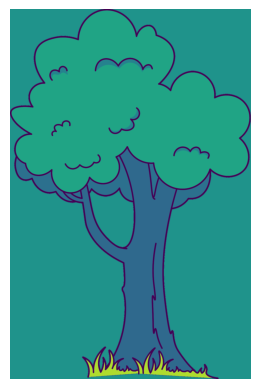

In [10]:
import cv2
import matplotlib.pyplot as plt

# Read image and convert to grayscale
img = cv2.imread("/content/tree-clipart.png")
# Loads the image using OpenCV.

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
# Converts the color image into a grayscale image.
# Each pixel now has one brightness value instead of 3 RGB values.

# Show grayscale image with different colormap
plt.imshow(gray, cmap='viridis')
# Displays the grayscale values using the 'viridis' color map.
# You can try: 'jet', 'plasma', 'cool', etc.

plt.axis("off")
# Hides the x and y axes.

plt.show()
# Displays the final image.


In [11]:
img.shape

(1920, 1250, 3)